# DermAssist — Lesion Segmentation and Feature Analysis

This notebook detects lesion regions, compares masks, extracts features, and evaluates the results.

### 1. Import libraries and set folders

Load the images without hair and the PH2 reference masks.

In [29]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


In [30]:
# Find the project folder

if (Path(".") / "PH2").exists():
    BASE_DIR = Path(".")
elif (Path("..") / "PH2").exists():
    BASE_DIR = Path("..")
else:
    raise FileNotFoundError("PH2 folder was not found.")

# Set input folders

image_dir = BASE_DIR / "outputs" / "Telea"

mask_dirs = [
    BASE_DIR / "PH2" / "trainy",
    BASE_DIR / "PH2" / "ph2_dataset" / "trainy"
]

# Set output folders

output_dir = BASE_DIR / "outputs" / "lesion_segmentation"

pred_mask_dir = output_dir / "predicted_masks"
overlay_dir = output_dir / "overlays"

pred_mask_dir.mkdir(parents=True, exist_ok=True)
overlay_dir.mkdir(parents=True, exist_ok=True)

# Find image files

image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]

image_paths = sorted([
    p for p in image_dir.rglob("*")
    if p.is_file() and p.suffix.lower() in image_extensions
]) if image_dir.exists() else []

mask_paths = []

for folder in mask_dirs:
    if folder.exists():
        mask_paths.extend([
            p for p in folder.rglob("*")
            if p.is_file() and p.suffix.lower() in image_extensions
        ])

mask_paths = sorted(mask_paths)

print("Project folder:", BASE_DIR.resolve())
print("Image folder:", image_dir)
print("Images:", len(image_paths))
print("Reference masks:", len(mask_paths))

Project folder: D:\CV\DermAssist
Image folder: ..\outputs\Telea
Images: 200
Reference masks: 400


### 2. Match images with reference masks

Match files by their names. Check the printed examples before continuing.

In [31]:
def file_key(path):
    # Normalize common filename differences
    name = path.stem.lower()
    for ending in ["_mask", "-mask", "_lesion", "-lesion", "_segmentation"]:
        name = name.replace(ending, "")
    return name

mask_lookup = {}
for path in mask_paths:
    mask_lookup[file_key(path)] = path

matched_pairs = []
for image_path in image_paths:
    key = file_key(image_path)
    if key in mask_lookup:
        matched_pairs.append((image_path, mask_lookup[key]))

print("Matched pairs:", len(matched_pairs))
for image_path, mask_path in matched_pairs[:10]:
    print(image_path.name, "->", mask_path.name)

if len(matched_pairs) == 0:
    print("No exact matches. Check the image and mask filenames.")

Matched pairs: 200
IMD002.bmp -> IMD002_lesion.bmp
IMD003.bmp -> IMD003_lesion.bmp
IMD004.bmp -> IMD004_lesion.bmp
IMD006.bmp -> IMD006_lesion.bmp
IMD008.bmp -> IMD008_lesion.bmp
IMD009.bmp -> IMD009_lesion.bmp
IMD010.bmp -> IMD010_lesion.bmp
IMD013.bmp -> IMD013_lesion.bmp
IMD014.bmp -> IMD014_lesion.bmp
IMD015.bmp -> IMD015_lesion.bmp


### 3. Create a lesion mask

Use a simple color-based threshold and morphological cleanup. This is a baseline method, so inspect its output carefully.

In [32]:
def make_lesion_mask(image):
    # Convert to grayscale and smooth small variations
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # Otsu thresholding separates darker regions
    _, mask = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Clean small gaps and isolated pixels
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # Keep the largest connected region
    count, labels, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
    if count > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask = np.uint8(labels == largest) * 255

    return mask

def read_image(path):
    return cv2.imread(str(path), cv2.IMREAD_COLOR)

def read_mask(path, shape):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None
    if mask.shape != shape[:2]:
        mask = cv2.resize(mask, (shape[1], shape[0]), interpolation=cv2.INTER_NEAREST)
    return np.uint8(mask > 0) * 255

segmentation_rows = []

for i, (image_path, mask_path) in enumerate(matched_pairs, start=1):
    image = read_image(image_path)
    if image is None:
        continue

    predicted = make_lesion_mask(image)
    reference = read_mask(mask_path, image.shape)
    if reference is None:
        continue

    cv2.imwrite(str(pred_mask_dir / f"{image_path.stem}_mask.png"), predicted)

    # Save a color overlay for quick review
    overlay = image.copy()
    overlay[predicted > 0] = (0, 0, 255)
    overlay = cv2.addWeighted(image, 0.65, overlay, 0.35, 0)
    cv2.imwrite(str(overlay_dir / f"{image_path.stem}_overlay.png"), overlay)

    intersection = np.logical_and(predicted > 0, reference > 0).sum()
    union = np.logical_or(predicted > 0, reference > 0).sum()
    dice = (2 * intersection) / ((predicted > 0).sum() + (reference > 0).sum() + 1e-8)
    iou = intersection / (union + 1e-8)
    disagreement = np.logical_xor(predicted > 0, reference > 0).mean() * 100

    segmentation_rows.append({
        "Image": image_path.name,
        "Mask": mask_path.name,
        "Dice": dice,
        "IoU": iou,
        "Pixel disagreement (%)": disagreement
    })

    if i % 20 == 0 or i == len(matched_pairs):
        print("Processed:", i)

segmentation_df = pd.DataFrame(segmentation_rows)
segmentation_df.head()

Processed: 20
Processed: 40
Processed: 60
Processed: 80
Processed: 100
Processed: 120
Processed: 140
Processed: 160
Processed: 180
Processed: 200


,Image,Mask,Dice,IoU,Pixel disagreement (%)
0,IMD002.bmp,IMD002_lesion.bmp,0.926666,0.863353,3.791764
1,IMD003.bmp,IMD003_lesion.bmp,0.942163,0.890651,1.303546
2,IMD004.bmp,IMD004_lesion.bmp,0.956021,0.915747,1.725763
3,IMD006.bmp,IMD006_lesion.bmp,0.706293,0.545945,6.784405
4,IMD008.bmp,IMD008_lesion.bmp,0.499448,0.332843,7.810234


### 4. Show segmentation results

Display the input image, detected lesion, and PH2 reference mask for a few matched samples.

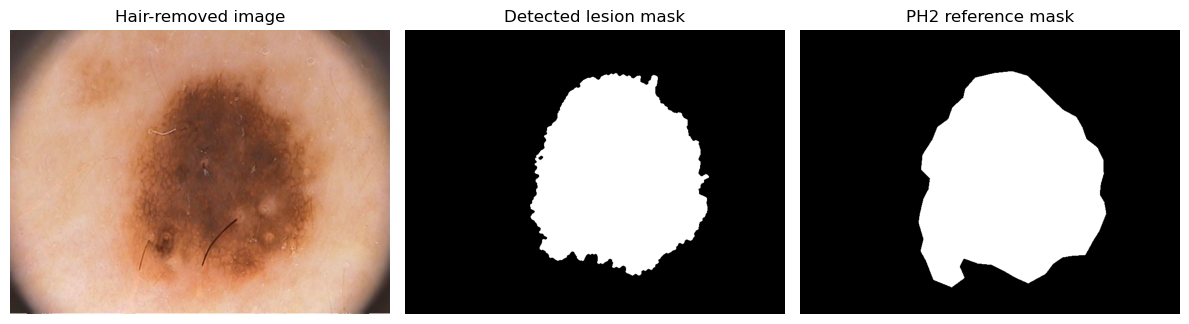

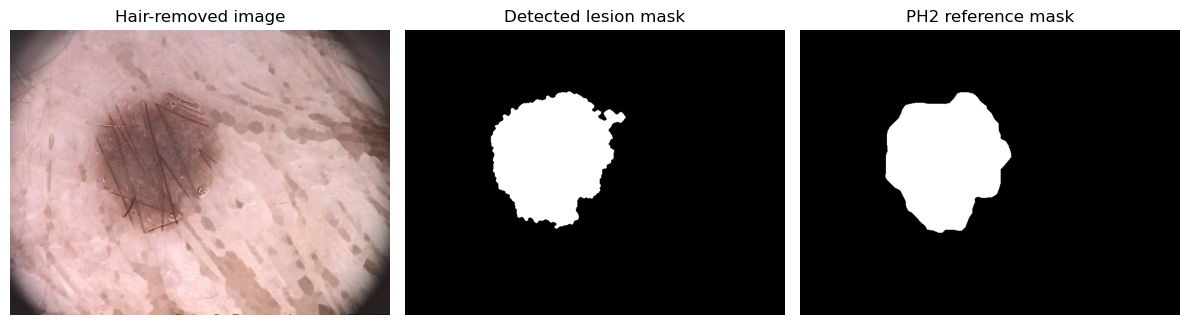

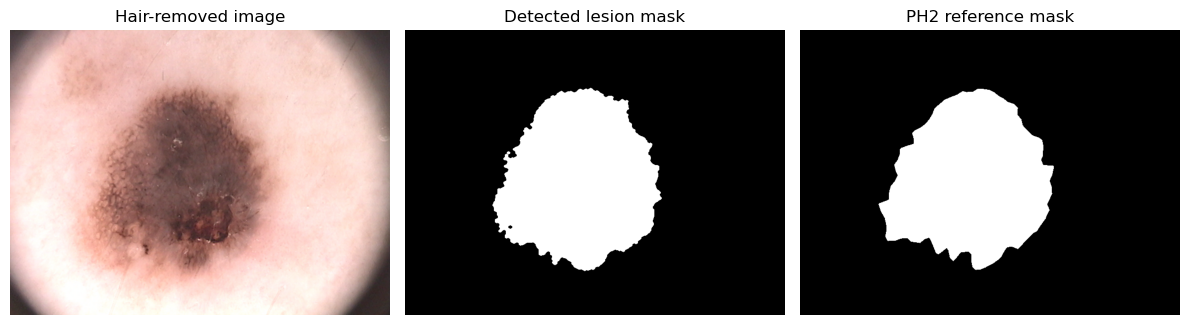

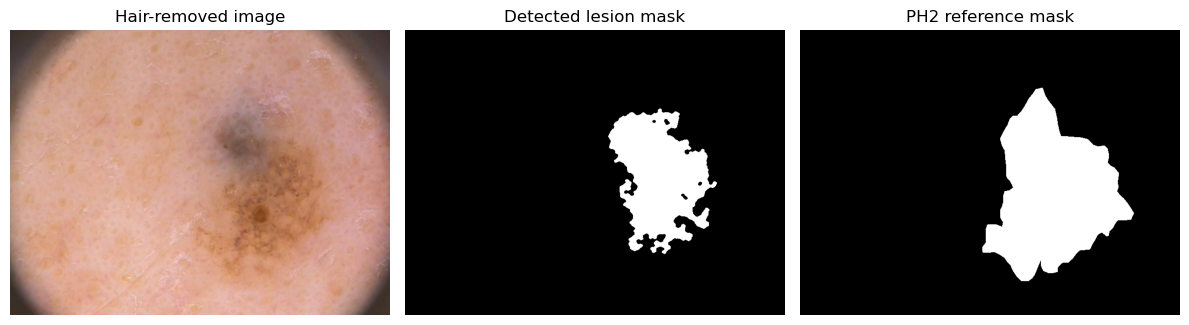

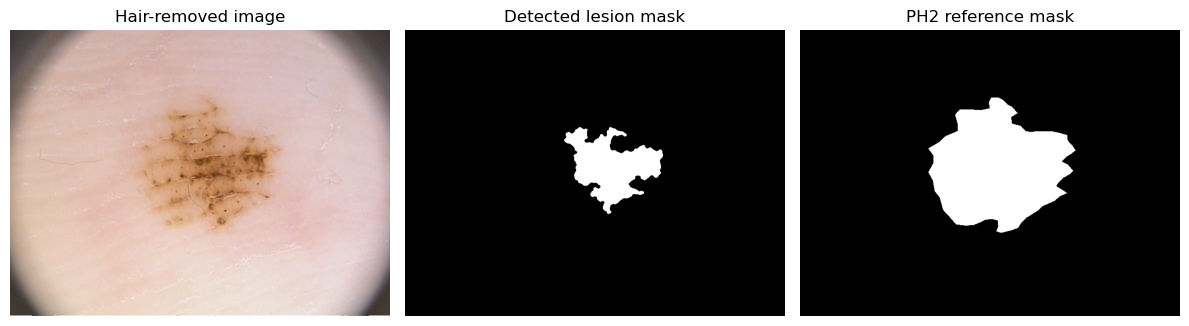

In [33]:
for image_path, mask_path in matched_pairs[:5]:
    image = read_image(image_path)
    if image is None:
        continue

    predicted = make_lesion_mask(image)
    reference = read_mask(mask_path, image.shape)

    if reference is None:
        continue

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Hair-removed image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(predicted, cmap="gray")
    plt.title("Detected lesion mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(reference, cmap="gray")
    plt.title("PH2 reference mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

### 5. Extract lesion features

Extract simple shape, color, and texture features from each predicted lesion region.

In [34]:
def extract_features(image, mask):
    binary = np.uint8(mask > 0)
    area = int(binary.sum())

    if area == 0:
        return None

    contours, _ = cv2.findContours(
        binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    perimeter = 0
    if contours:
        contour = max(contours, key=cv2.contourArea)
        perimeter = cv2.arcLength(contour, True)

    # Shape features
    circularity = (4 * np.pi * area) / (perimeter ** 2 + 1e-8)
    x, y, w, h = cv2.boundingRect(binary)
    aspect_ratio = w / (h + 1e-8)

    # Color features inside the lesion
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    b, g, r = cv2.split(image)
    lesion_pixels = binary > 0

    mean_r = float(r[lesion_pixels].mean())
    mean_g = float(g[lesion_pixels].mean())
    mean_b = float(b[lesion_pixels].mean())
    mean_h = float(hsv[:, :, 0][lesion_pixels].mean())
    mean_s = float(hsv[:, :, 1][lesion_pixels].mean())
    mean_v = float(hsv[:, :, 2][lesion_pixels].mean())

    # Grayscale intensity variation
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    mean_gray = float(gray[lesion_pixels].mean())
    std_gray = float(gray[lesion_pixels].std())

    return {
        "Area": area,
        "Perimeter": float(perimeter),
        "Circularity": float(circularity),
        "Aspect ratio": float(aspect_ratio),
        "Mean R": mean_r,
        "Mean G": mean_g,
        "Mean B": mean_b,
        "Mean H": mean_h,
        "Mean S": mean_s,
        "Mean V": mean_v,
        "Mean gray": mean_gray,
        "Gray std": std_gray
    }

feature_rows = []

for image_path, mask_path in matched_pairs:
    image = read_image(image_path)
    if image is None:
        continue

    predicted = make_lesion_mask(image)
    features = extract_features(image, predicted)

    if features is not None:
        features["Image"] = image_path.name
        feature_rows.append(features)

features_df = pd.DataFrame(feature_rows)
features_df.head()

,Area,Perimeter,Circularity,Aspect ratio,Mean R,Mean G,Mean B,Mean H,Mean S,Mean V,Mean gray,Gray std,Image
0,105976,1623.339302,0.505358,0.884521,138.412735,79.247632,51.678795,9.344059,159.449989,138.412735,93.795661,20.108086,IMD002.bmp
1,49092,1133.668168,0.480008,0.981884,139.153874,98.462499,94.284344,17.674652,83.096615,139.153935,110.153895,18.782970,IMD003.bmp
2,86926,1461.658064,0.511291,0.926630,137.023296,92.288774,85.543543,10.003187,95.693740,137.023296,104.899535,26.901287,IMD004.bmp
3,36872,1661.138290,0.167917,0.747440,164.782382,112.205359,85.852652,10.349344,120.836054,164.782382,124.922570,12.395519,IMD006.bmp
4,17192,988.028560,0.221308,1.130682,180.432003,122.616566,78.469055,12.969172,146.051536,180.432003,134.874884,20.590223,IMD008.bmp


### 6. Analyze extracted features

Review summary statistics and visualize selected feature relationships.

,Area,Perimeter,Circularity,Aspect ratio,Mean R,Mean G,Mean B,Mean H,Mean S,Mean V,Mean gray,Gray std
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,103741.835000,1921.860980,0.384003,1.009727,150.069729,94.407966,68.787385,21.516095,133.941908,150.097009,108.132392,19.733951
std,77551.428684,1068.996927,0.164709,0.274619,36.701074,20.039501,21.568112,28.917576,39.101267,36.670316,23.254520,5.467505
min,12854.000000,506.416300,0.050140,0.269097,66.246770,42.100585,21.080607,4.232200,14.969490,66.975786,48.397835,9.443557
25%,41309.500000,1168.180361,0.257853,0.859741,122.707643,82.293647,53.549870,9.659730,103.921559,122.711921,91.508536,15.472073
50%,85454.000000,1603.481437,0.366719,1.012772,152.893181,93.347522,66.383448,11.466573,141.479909,153.009226,109.180263,18.847593
75%,152323.500000,2306.436101,0.506890,1.189731,175.777648,109.853401,82.770148,15.161179,164.464906,175.781509,125.065972,22.725995
max,361034.000000,5672.218917,0.767013,1.858268,235.433072,147.891870,128.641614,158.540826,211.603388,235.433072,165.173852,36.760525


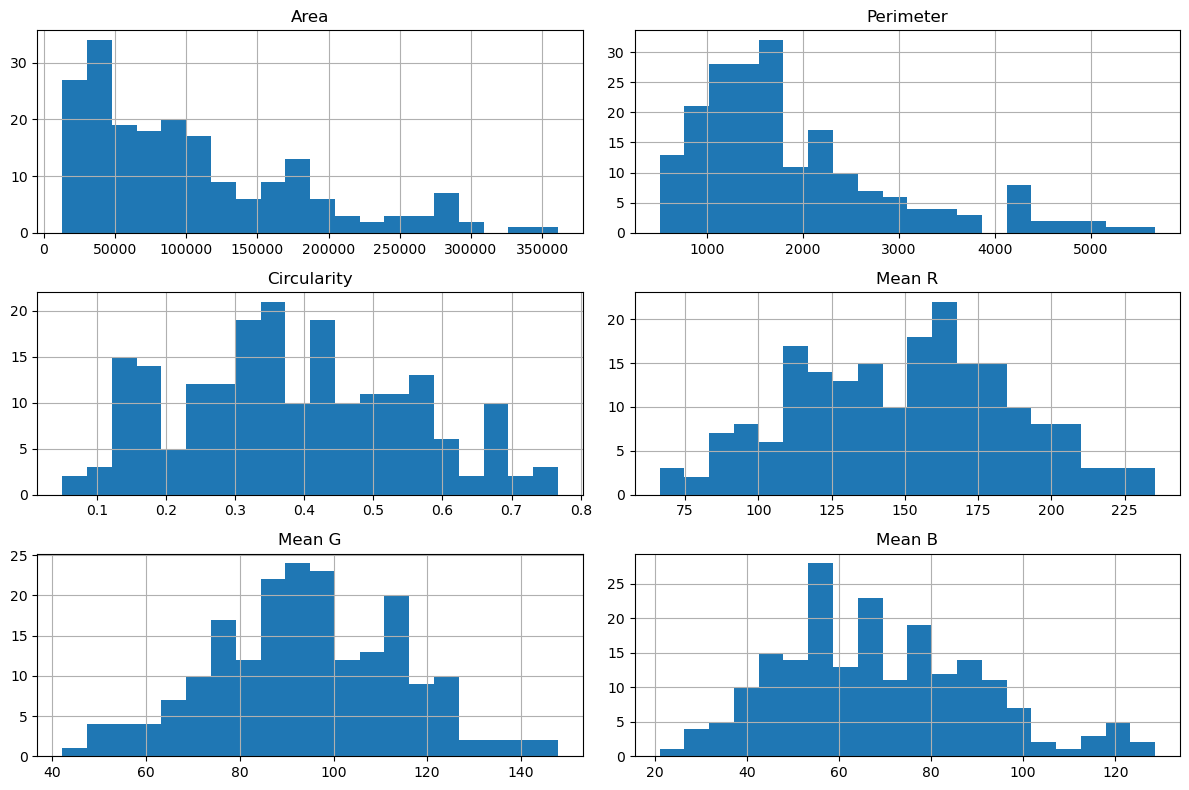

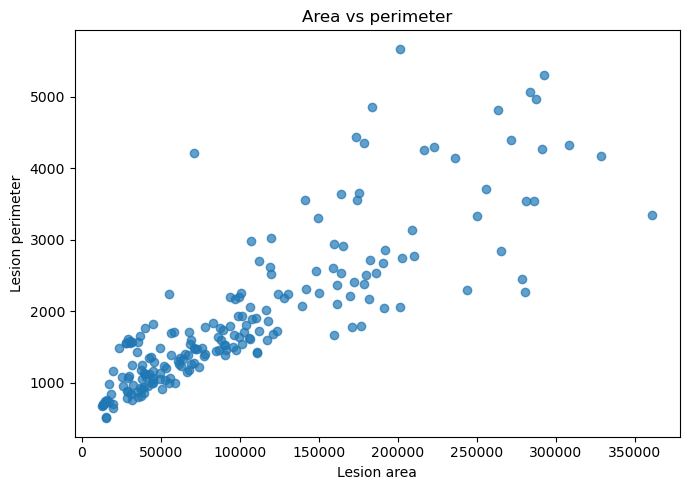

In [35]:
if not features_df.empty:
    display(features_df.describe())

    plot_columns = ["Area", "Perimeter", "Circularity", "Mean R", "Mean G", "Mean B"]
    features_df[plot_columns].hist(figsize=(12, 8), bins=20)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.scatter(features_df["Area"], features_df["Perimeter"], alpha=0.7)
    plt.xlabel("Lesion area")
    plt.ylabel("Lesion perimeter")
    plt.title("Area vs perimeter")
    plt.tight_layout()
    plt.show()
else:
    print("No features were extracted.")

## Clustering Images Using 12 Features

In this step, the images are divided into two groups using all 12 extracted features.

Before clustering, the features are standardized because they have different scales.
After clustering, one plot is created for each feature to show how the two groups are distributed.

The groups are based only on feature similarity and do not represent medical diagnosis.

c:\Users\Mohadese\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Group 0: 100
Group 1: 100


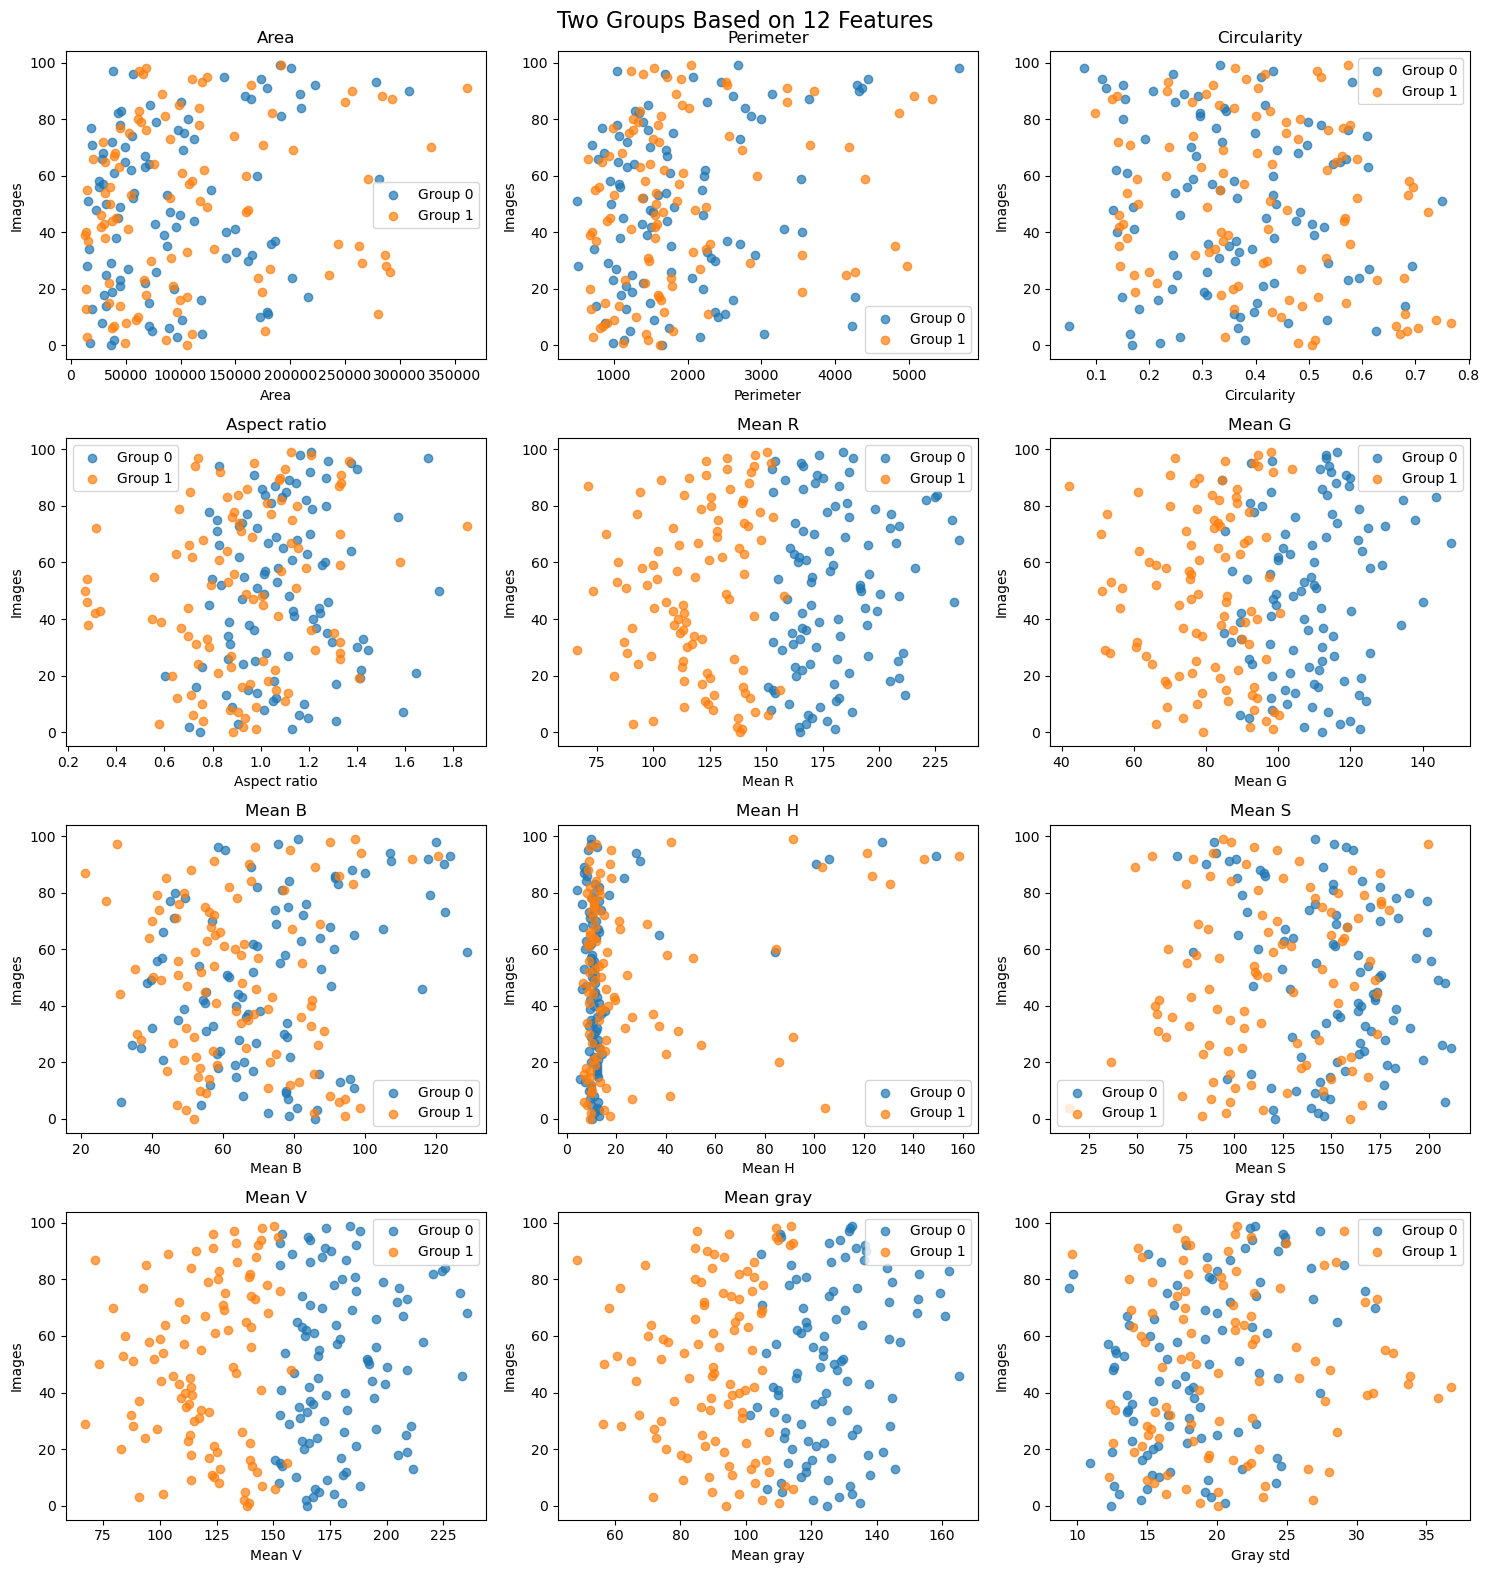

In [36]:


feature_columns = [
    "Area", "Perimeter", "Circularity", "Aspect ratio",
    "Mean R", "Mean G", "Mean B",
    "Mean H", "Mean S", "Mean V",
    "Mean gray", "Gray std"
]

# Use all 12 features
X = features_df[feature_columns].copy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Divide images into two groups
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
features_df["Group"] = kmeans.fit_predict(X_scaled)

print("Group 0:", (features_df["Group"] == 0).sum())
print("Group 1:", (features_df["Group"] == 1).sum())

# Show all 12 features
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.ravel()

for i, feature in enumerate(feature_columns):

    for group in [0, 1]:
        group_data = features_df[features_df["Group"] == group]

        axes[i].scatter(
            group_data[feature],
            range(len(group_data)),
            label=f"Group {group}",
            alpha=0.7
        )

    axes[i].set_title(feature)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Images")
    axes[i].legend()

plt.suptitle("Two Groups Based on 12 Features", fontsize=16)
plt.tight_layout()
plt.show()

## From Clustering to Feature Analysis

At first, K-Means clustering was used to divide the images into two groups based on the 12 extracted features.

However, the two groups were not clearly separated. The clustering was only an exploratory analysis and did not represent medical classes.

Also, the available dataset does not contain diagnostic labels in the current dataset structure. Therefore, we cannot evaluate or build a reliable medical classification.

For this reason, we do not use the K-Means groups as a final result.

Instead, we analyze the 12 extracted features in more detail.

## Feature Analysis

The extracted features describe the lesion from three main aspects:

- Shape features
- Color features
- Intensity features

In this step, we study the distribution, variation, and relationships between these features.

## Descriptive Statistics

First, descriptive statistics are calculated for all 12 features.

The results include the number of samples, mean, standard deviation, minimum, maximum, and quartiles.

This helps us understand the general range and variation of each feature.

## Feature Distributions

Histograms are used to visualize the distribution of each feature.

These plots help us see how the values are distributed and whether some features have a narrow or wide range.

They can also show possible outliers or unusual values.

## Shape Features

The shape features describe the geometric properties of the lesion.

The extracted shape features are:

- Area
- Perimeter
- Circularity
- Aspect ratio

Area and perimeter describe the size and boundary of the lesion.

Circularity describes how close the lesion shape is to a circle.

Aspect ratio describes the relationship between the width and height of the lesion.

## Color Features

Color features describe the color characteristics of the lesion.

The extracted color features are:

- Mean R
- Mean G
- Mean B
- Mean H
- Mean S
- Mean V

The RGB features describe the average red, green, and blue values.

The HSV features describe hue, saturation, and brightness information.

## Intensity Features

Two grayscale features are extracted:

- Mean gray
- Gray std

Mean gray represents the average intensity inside the lesion.

Gray std represents the variation of intensity inside the lesion.

A higher standard deviation means that the intensity values are more varied.

## Feature Variation

The standard deviation and range of each feature are examined to understand how much the values vary between images.

Features with larger variation may describe stronger differences between lesions.

However, a large variation does not necessarily indicate a medical difference because the dataset does not provide diagnostic labels in the current structure.

## Feature Correlation

A correlation matrix is used to study the relationships between the 12 features.

Highly correlated features may contain similar information.

For example, Area and Perimeter may have a relationship because larger lesions often have longer boundaries.

Similarly, RGB and HSV features may contain related color information.

Correlation does not mean that one feature causes another.

## Correlation Heatmap

The correlation matrix is visualized as a heatmap.

The heatmap makes it easier to identify strong positive and negative relationships between features.

Features with a correlation close to +1 or -1 have a strong linear relationship, while values close to 0 indicate a weak linear relationship.

## Area vs Perimeter

The relationship between lesion area and perimeter is visualized using a scatter plot.

This helps us understand whether larger lesions generally have longer boundaries.

The plot also helps identify unusual samples that do not follow the general pattern.

## Shape Feature Relationships

The relationships between Area, Perimeter, Circularity, and Aspect Ratio are examined.

These plots help us understand how different geometric properties change together.

This is useful for identifying redundant or complementary shape features.

## Color Feature Relationships

The relationships between RGB and HSV features are analyzed.

Since both color spaces describe the same lesion pixels in different ways, some of their features may be strongly correlated.

This analysis helps identify which color features provide similar information.

## Feature Analysis Summary

The extracted 12 features provide information about lesion shape, color, and intensity.

The shape features describe the geometry of the lesion, while the color and intensity features describe its visual characteristics.

K-Means clustering was initially tested, but it did not produce clearly separated groups. Since the available dataset does not provide diagnostic labels in the current dataset structure, the groups cannot be interpreted as medical classes.

Therefore, the final analysis focuses on the distribution, variation, and correlation of the extracted features.

This analysis provides a better understanding of the dataset and can be used as a foundation for future work if reliable diagnostic labels become available.